# E02. Evaluate Players
- This evaluates player projections
- Type: Evaluation
- Run Frequency: Irregular
- Sources:
    - Daily Fantasy Fuel
    - Player Results (MLB API)
- Created: 3/30/2024
- Updated: 8/5/2025

### Imports

In [1]:
from DataImports import *

### Dates

In [2]:
start_date, end_date = "20240101", "20240930"
start_date, end_date = "20250101", "20251231"
# start_date, end_date = todaysdate, todaysdate

### Data

##### Games

In [3]:
# %%time
# historic_game_df = pd.read_csv(os.path.join(baseball_path, "game_df.csv"))
# recent_game_df = create_games(yesterdaysdate, todaysdate, team_dict)
# historic_game_df = historic_game_df[~historic_game_df['date'].astype(str).isin([yesterdaysdate, todaysdate])]
# all_game_df = pd.concat([historic_game_df, recent_game_df], axis=0)
# all_game_df.to_csv(os.path.join(baseball_path, "game_df.csv"), index=False)

In [4]:
%%time
all_game_df = pd.read_csv(os.path.join(baseball_path, "game_df.csv"))

CPU times: total: 15.6 ms
Wall time: 22.4 ms


In [5]:
game_df = all_game_df[(all_game_df['date'].astype(str) >= start_date) & (all_game_df['date'].astype(str) <= end_date)].reset_index(drop=True)

In [6]:
game_df = game_df[game_df['current_inning'] >= 9].reset_index(drop=True)  # Only completed games

##### Player Projections

In [7]:
def load_matchup_csvs_parallel(root_path, start_date, end_date, file_prefix):
    target_name = f"{file_prefix}.csv"
    s = int(start_date)
    e = int(end_date)

    # collect all file paths first (fast, single-threaded)
    file_paths = []

    for folder in os.listdir(root_path):
        if folder.startswith("Matchups "):
            date_str = folder.split("Matchups ")[1]
            if len(date_str) == 8 and date_str.isdigit():
                date_val = int(date_str)
                if s <= date_val <= e:
                    folder_path = os.path.join(root_path, folder)
                    for root, dirs, files in os.walk(folder_path):
                        if target_name in files:
                            file_paths.append(os.path.join(root, target_name))

    if not file_paths:
        return pd.DataFrame()

    # load CSVs in parallel
    dfs = Parallel(n_jobs=-1)(delayed(pd.read_csv)(fp) for fp in file_paths)

    return pd.concat(dfs, ignore_index=True)

Batters

In [8]:
%%time
batters_df  = load_matchup_csvs_parallel(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims"), start_date, end_date, "batters") 

CPU times: total: 13.4 s
Wall time: 14.2 s


Pitchers

In [9]:
%%time
pitchers_df  = load_matchup_csvs_parallel(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims"), start_date, end_date, "pitchers") 

CPU times: total: 18.7 s
Wall time: 19 s


In [10]:
pitchers_df.head()

,id,fullName,imp_p_l,imp_p_r,confirmed,OUT,SO,HBP,BB,B1,B2,B3,HR,H,R,ER,W,CG,CGSO,NH,FP,PA,team,away_score,home_score,sim,game_id
0,808967.000000,Yoshinobu Yamamoto,0.000000,0.000000,NaN,17,5,0,1,0,1,0,1,2,2,2,0,0,0,0,16.950000,19,away,3,2,0,778563
1,472610.000000,Luis Garcia,0.000000,0.000000,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.750000,1,away,3,2,0,778563
2,676508.000000,Ben Casparius,1.000000,1.000000,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,away,3,2,0,778563
3,607455.000000,Anthony Banda,0.000000,0.000000,NaN,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.250000,3,away,3,2,0,778563
4,680736.000000,Justin Wrobleski,0.000000,0.000000,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,away,3,2,0,778563


##### Player Results

In [11]:
from joblib import Parallel, delayed

def load_player_results(root_path, game_df, prefixes):
    # prefixes example: ["away batters", "home batters"]
    game_ids = set(game_df["game_id"].astype(str).unique())

    file_paths = []

    # find all file paths
    for game_id in game_ids:
        folder_name = f"Player Results {game_id}"
        folder_path = os.path.join(root_path, folder_name)

        if not os.path.isdir(folder_path):
            continue

        for root, dirs, files in os.walk(folder_path):
            for f in files:
                for p in prefixes:
                    if f.startswith(p):
                        file_paths.append(os.path.join(root, f))
                        break

    if not file_paths:
        return pd.DataFrame()

    dfs = Parallel(n_jobs=-1)(
        delayed(pd.read_csv)(fp, encoding="iso-8859-1")
        for fp in file_paths
    )

    return pd.concat(dfs, ignore_index=True)


Batters

In [12]:
%%time
batter_results_df = load_player_results(os.path.join(baseball_path, "A01. Player Results"), game_df, prefixes=["away batters", "home batters"])

CPU times: total: 1.75 s
Wall time: 1.98 s


Pitchers

In [13]:
%%time
pitcher_results_df = load_player_results(os.path.join(baseball_path, "A01. Player Results"), game_df, prefixes=["away pitchers", "home pitchers"])

CPU times: total: 1.38 s
Wall time: 1.35 s


In [14]:
pitcher_results_df.head()

,name,personId,starter,ip,pa,outs,h,r,er,bb,k,hr,hbp,w,l,cg,cgso,nh,fp,gamePk,date,year,venue_id,team,teamabbrev
0,Springs,605488,1,5.000000,21.000000,15,3,3,3,3,4,1,0,1,0,0,0,0,13.650000,778309,20250415,2025,4,away,OAK
1,Sterner,686993,0,1.000000,5.000000,3,1,0,0,1,2,0,0,0,0,0,0,0,5.050000,778309,20250415,2025,4,away,OAK
2,Spence,687765,0,3.000000,11.000000,9,2,0,0,0,2,0,0,0,0,0,0,0,9.550000,778309,20250415,2025,4,away,OAK
3,"Burke, S",680732,1,3.100000,18.000000,10,6,5,5,2,2,2,0,0,1,0,0,0,-3.300000,778309,20250415,2025,4,home,CHW
4,Eisert,685126,0,1.200000,6.000000,5,1,0,0,0,2,0,0,0,0,0,0,0,7.150000,778309,20250415,2025,4,home,CHW


##### DFF Projections

DFF - Date-Based

DFF projections from when I extracted only one set of projections per day

In [15]:
# Set the directory path
directory = os.path.join(baseball_path, "A08. Projections", "1. DFF", "2. Projections", "Date")

# Initialize an empty list to store dataframes
dfs = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Check if the file is a CSV file
        # Read the CSV file into a pandas dataframe
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath, dtype='str')
        dfs.append(df)  # Append the dataframe to the list

# Concatenate all dataframes into a single dataframe
dff_date_df = pd.concat(dfs, ignore_index=True)

# Drop duplicates based on "First Name", "Last Name", and "date"
dff_date_df.drop_duplicates(subset=["first_name", "last_name", "game_date"], inplace=True)

# Print the resulting dataframe
print(dff_date_df.shape)

(40795, 22)


DFF - Slate-Based

DFF projections from when I extract one set of projections per slate

In [16]:
# Set the directory path
directory = os.path.join(baseball_path, "A08. Projections", "1. DFF", "2. Projections")


# Initialize an empty list to store dataframes
dfs = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # Check if the file is a CSV file
        # Read the CSV file into a pandas dataframe
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath, dtype='str')
        dfs.append(df)  # Append the dataframe to the list

# Concatenate all dataframes into a single dataframe
dff_slate_df = pd.concat(dfs, ignore_index=True)

# Drop duplicates based on "First Name", "Last Name", and "date"
dff_slate_df.drop_duplicates(subset=["First Name", "Last Name", "date"], inplace=True)

# Print the resulting dataframe
print(dff_slate_df.shape)

(125712, 22)


### Clean

##### Player Projections

In [17]:
batters_df['H'] = batters_df[['B1', 'B2', 'B3', 'HR']].sum(axis=1)
batters_df['ON'] = batters_df[['H', 'BB', 'HBP']].sum(axis=1)

##### Player Results

In [18]:
batter_results_df['singles'] = batter_results_df['h'] - batter_results_df['doubles'] - batter_results_df['triples'] - batter_results_df['hr']
batter_results_df['pa'] = batter_results_df[['ab', 'bb', 'hbp']].sum(axis=1)
batter_results_df['on'] = batter_results_df[['h', 'bb', 'hbp']].sum(axis=1)

In [19]:
# Identify number of batters that batted in a given spot in the order (we may only want those who were never subbed out or are subs)
batter_results_df['battingSpot'] = batter_results_df['battingOrder'] // 100
# Instance of batter in that spot
# Example:
# Three batters batted 4
# All three would have battingSpot = 4
# battingSpotInstance for starter would be 1, the first sub would be 2, second sub would be 3
batter_results_df['battingSpotInstance'] = batter_results_df.groupby(['gamePk', 'team', 'battingSpot'])['battingSpot'].transform('count')

In [20]:
import statsapi
import pandas as pd

def get_batter_pa(gamePk: int):
    """Extract plate appearances for every batter in an MLB box score, robust to data format changes."""
    data = statsapi.boxscore_data(gamePk)
    
    rows = []
    for team_side in ["home", "away"]:
        # Try the most common locations for team name
        team_name = None
        if "team" in data[team_side]:
            team_info = data[team_side]["team"]
            if isinstance(team_info, dict):
                team_name = team_info.get("name") or team_info.get("abbreviation")
            elif isinstance(team_info, list) and team_info:
                team_name = team_info[0].get("name") or team_info[0].get("abbreviation")
        if not team_name:  # fallback
            for item in data[team_side].get("info", []):
                if item.get("title") == "Team":
                    team_name = item.get("fieldList", [{}])[0].get("value")
                    break
        if not team_name:
            team_name = team_side.capitalize()

        players = data[team_side]["players"]

        for pid, pdata in players.items():
            batting = pdata.get("stats", {}).get("batting")
            if not batting:
                continue  # skip players who did not bat

            # Compute PA if missing
            AB = batting.get("atBats", 0)
            BB = batting.get("baseOnBalls", 0)
            HBP = batting.get("hitByPitch", 0)
            SF = batting.get("sacFlies", 0)
            SH = batting.get("sacBunts", 0)
            CI = batting.get("catchersInterference", 0)

            PA = batting.get("plateAppearances", AB + BB + HBP + SF + SH + CI)

            rows.append({
                "player_id": pid,
                "name": pdata["person"]["fullName"],
                "team": team_name,
                "PA": PA,
                "AB": AB,
                "BB": BB,
                "HBP": HBP,
                "SF": SF,
                "SH": SH,
                "CI": CI,
            })

    return pd.DataFrame(rows)


# Example:
df = get_batter_pa(745678)
df.describe()


,PA,AB,BB,HBP,SF,SH,CI
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,3.181818,3.000000,0.181818,0.000000,0.000000,0.000000,0.000000
std,1.258736,1.414214,0.394771,0.000000,0.000000,0.000000,0.000000
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.250000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,3.500000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000


##### DFF Projections

Clean name and date

In [21]:
dff_date_df.rename(columns={'first_name':'First Name', 'last_name':'Last Name', 'ppg_projection':'FP', 'team':'Team'}, inplace=True)
dff_date_df['date'] = dff_date_df['game_date'].str.replace("-", "").astype('int')

Combine DFF dataframes

In [22]:
dff_df = pd.concat([dff_date_df[['First Name', 'Last Name', 'Team', 'FP', 'date']], dff_slate_df[['First Name', 'Last Name', 'FP', 'Team', 'date']]], axis=0)

Clean name

In [23]:
dff_df['fullName'] = dff_df['First Name'] + " " + dff_df['Last Name']
dff_df.rename(columns={'FP': 'FP_DFF'}, inplace=True)

Only keep one instance per player per game

Note: doubleheaders could be confused here - consider dropping both?

In [24]:
dff_df = dff_df.drop_duplicates(subset=['fullName', 'date', 'FP_DFF'])

Format data types

In [25]:
dff_df['FP_DFF'] = dff_df['FP_DFF'].astype('float')
dff_df['date'] = pd.to_numeric(dff_df['date'], errors='coerce')

### Merge

##### Batters

In [26]:
# Merge simulation results with actual player results
batter_dataset = pd.merge(batters_df[batters_df['sim'] < 500], batter_results_df.drop(columns=['team', 'teamabbrev', 'name', 'date', 'substitution']), left_on=['game_id', 'id',], right_on=['gamePk', 'personId'], how='left')
# Merge with actual scores
batter_dataset = pd.merge(batter_dataset, game_df[['game_id', 'venue_name', 'date', 'away_team', 'home_team', 'away_score', 'home_score']], on=['game_id'], how='left', suffixes=('_proj', ""))
# Merge with projections
batter_dataset = pd.merge(batter_dataset, dff_df[['fullName', 'date', 'FP_DFF']], on=['fullName', 'date'], how='left')

##### Pitchers

In [27]:
# Merge simulation results with actual player results
pitcher_dataset = pd.merge(pitchers_df[pitchers_df['sim'] < 500], pitcher_results_df.drop(columns=['team', 'name', 'date']), left_on=['game_id', 'id',], right_on=['gamePk', 'personId'], how='left')
# Merge with actual scores
pitcher_dataset = pd.merge(pitcher_dataset, game_df[['game_id', 'venue_name', 'date', 'away_team', 'home_team', 'away_score', 'home_score']], on=['game_id'], how='left', suffixes=('_proj', ""))
# Merge with projections
pitcher_dataset = pd.merge(pitcher_dataset, dff_df[['fullName', 'date', 'FP_DFF']], on=['fullName', 'date'], how='left')

### 1. Player Stat Evaluations

In [28]:
def compare_player_means(group, pairs):
    """
    Compute means and % of PA/pa for a list of projection vs actual stat pairs.
    
    group : pd.DataFrame
        Grouped player stats
    pairs : list of tuples
        Each tuple: (projection_col, actual_col)
    
    Returns:
        pd.DataFrame with columns: Stat, Projection, Actual, Projection%, Actual%
    """

    rows = []

    # PA for percentage calculations
    mean_PA = group['PA'].mean() if 'PA' in group else 1
    mean_pa = group['pa'].mean() if 'pa' in group else 1

    for projection, actual in pairs:
        proj_mean = group[projection].mean() if projection in group else 0
        act_mean  = group[actual].mean() if actual in group else 0

        proj_pct = proj_mean / mean_PA if mean_PA != 0 else 0
        act_pct  = act_mean / mean_pa if mean_pa != 0 else 0

        rows.append({
            "Stat": projection,
            "Projection": proj_mean,
            "Actual": act_mean,
            "Projection%": proj_pct,
            "Actual%": act_pct,
        })

    return pd.DataFrame(rows)


In [29]:
batter_pairs = [
    ('PA', 'pa'),
    ('ON', 'on'),
    ('BB', 'bb'),
    ('B1', 'singles'),
    ('B2', 'doubles'),
    ('B3', 'triples'),
    ('HR', 'hr'),
    ('SB', 'sb'),
    ('R', 'r'),
    ('RBI', 'rbi'),
    ('FP', 'fp'),
]

In [30]:
pitcher_pairs = [
    ('PA', 'pa'),
    ('OUT', 'outs'),
    ('ER', 'er'),
    ('R', 'r'),
    ('H', 'h'),
    ('SO', 'k'),
    ('W', 'w'),
    ('FP', 'fp'),
]

##### 1A. Unimputed Starting Batters

In [31]:
compare_player_means(batter_dataset.query('battingSpotInstance == 1').query('imp_b_l == 0 & imp_b_r == 0').groupby(['game_id', 'id']).mean(numeric_only=True), batter_pairs)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,4.334083,4.120119,1.000000,1.000000
1,ON,1.440805,1.288252,0.332436,0.312673
2,BB,0.429794,0.354721,0.099166,0.086095
3,B1,0.610579,0.602142,0.140879,0.146147
4,B2,0.193287,0.178942,0.044597,0.043431
5,B3,0.019174,0.014895,0.004424,0.003615
6,HR,0.135024,0.137551,0.031154,0.033385
7,SB,0.081228,0.077805,0.018742,0.018884
8,R,0.532066,0.500016,0.122763,0.121360
9,RBI,0.507584,0.486868,0.117115,0.118168


##### 1B. Imputed Starting Batters

In [32]:
compare_player_means(batter_dataset.query('battingSpotInstance == 1').query('imp_b_l == 1 | imp_b_r == 1').groupby(['game_id', 'id']).mean(numeric_only=True), batter_pairs)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,4.131276,3.933984,1.000000,1.000000
1,ON,1.251679,1.168389,0.302976,0.296999
2,BB,0.363467,0.300804,0.087979,0.076463
3,B1,0.554563,0.579411,0.134235,0.147283
4,B2,0.162685,0.172599,0.039379,0.043874
5,B3,0.016665,0.014160,0.004034,0.003599
6,HR,0.103375,0.101416,0.025023,0.025779
7,SB,0.065751,0.075201,0.015915,0.019116
8,R,0.442050,0.455989,0.107001,0.115910
9,RBI,0.430269,0.422503,0.104149,0.107398


##### 1C. Team Batters

In [33]:
compare_player_means(batter_dataset.groupby(['game_id', 'team', 'sim']).sum(numeric_only=True), batter_pairs)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,38.621849,35.411535,1.000000,1.000000
1,ON,12.646112,10.984389,0.327434,0.310192
2,BB,3.761778,3.010408,0.097400,0.085012
3,B1,5.391281,5.169991,0.139591,0.145997
4,B2,1.687568,1.546184,0.043695,0.043663
5,B3,0.168283,0.126626,0.004357,0.003576
6,HR,1.163896,1.131180,0.030136,0.031944
7,SB,0.696526,0.653946,0.018035,0.018467
8,R,4.637542,4.227450,0.120076,0.119381
9,RBI,4.441696,4.085863,0.115005,0.115382


##### 1D. Unimputed Starting Pitchers

In [34]:
compare_player_means(pitcher_dataset.query('starter == 1').query('imp_p_l == 0 & imp_p_r == 0').groupby(['game_id', 'id']).mean(numeric_only=True), pitcher_pairs)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,18.869265,20.575574,1.000000,1.000000
1,OUT,13.360499,14.637349,0.708056,0.711394
2,ER,1.958776,2.165060,0.103808,0.105225
3,R,2.136265,2.324096,0.113214,0.112954
4,H,4.187482,4.522892,0.221921,0.219818
5,SO,4.249287,4.483133,0.225196,0.217886
6,W,0.260320,0.283133,0.013796,0.013761
7,FP,12.178261,13.007530,0.645402,0.632183


##### 1E. Imputed Starting Pitchers

In [35]:
compare_player_means(pitcher_dataset.query('starter == 1').query('imp_p_l == 1 | imp_p_r == 1').groupby(['game_id', 'id']).mean(numeric_only=True), pitcher_pairs)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,8.120034,17.494382,1.000000,1.000000
1,OUT,5.551000,12.157303,0.683618,0.694926
2,ER,0.951640,2.073034,0.117197,0.118497
3,R,1.033809,2.252809,0.127316,0.128773
4,H,1.817618,4.000000,0.223844,0.228645
5,SO,1.616955,3.662921,0.199132,0.209377
6,W,0.084180,0.213483,0.010367,0.012203
7,FP,4.201828,9.844944,0.517464,0.562749


##### 1F. Team Pitchers

In [36]:
compare_player_means(pitcher_dataset.groupby(['game_id', 'team', 'sim']).sum(numeric_only=True), pitcher_pairs)

,Stat,Projection,Actual,Projection%,Actual%
0,PA,38.621849,18.959670,1.000000,1.000000
1,OUT,26.712471,13.399827,0.691641,0.706754
2,ER,4.183274,2.004337,0.108314,0.105716
3,R,4.637542,2.208803,0.120076,0.116500
4,H,8.411027,4.076973,0.217779,0.215034
5,SO,8.546906,4.329792,0.221297,0.228369
6,W,0.500000,0.250867,0.012946,0.013232
7,FP,23.184897,12.224913,0.600305,0.644785


### 2. Competitor Projection Evaluations

Compare my simulated projections to other source(s) of player fantasy point projections

##### 2A. Batter FP Distributions

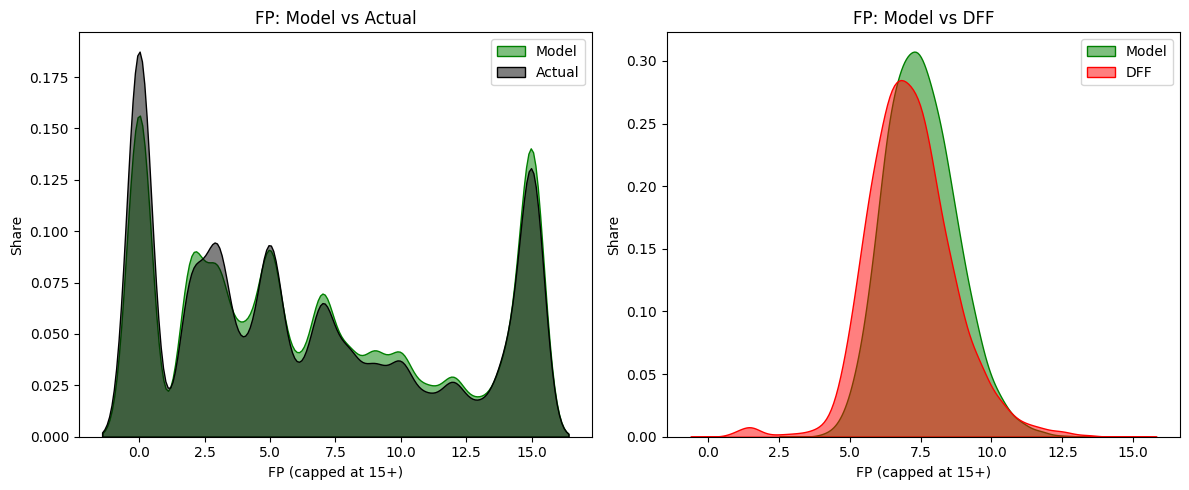

CPU times: total: 1min 36s
Wall time: 1min 34s


In [37]:
%%time
# Cap FP values at 15+
FP_capped = np.minimum(batter_dataset.query('battingSpotInstance == 1')['FP'], 15)
fp_capped = np.minimum(batter_dataset.query('battingSpotInstance == 1')['fp'], 15)

plt.figure(figsize=(12, 5))

# Histogram 1: FP vs fp (Model vs Actual)
plt.subplot(1, 2, 1)
sns.kdeplot(FP_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=2.5)
sns.kdeplot(fp_capped, fill=True, color='black', alpha=0.5, label='Actual', bw_adjust=2.5)
plt.xlabel('FP (capped at 15+)')
plt.ylabel('Share')
plt.title('FP: Model vs Actual')
plt.legend()

# Histogram 2: FP vs FP_DFF (grouped, capped)
grouped = batter_dataset.groupby(['game_id', 'id']).mean(numeric_only=True).reset_index()
FP_grouped_capped = np.minimum(grouped['FP'], 15)
FP_DFF_capped = np.minimum(grouped['FP_DFF'], 15)

plt.subplot(1, 2, 2)
sns.kdeplot(FP_grouped_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=1.5)
sns.kdeplot(FP_DFF_capped, fill=True, color='red', alpha=0.5, label='DFF', bw_adjust=1.5)
plt.xlabel('FP (capped at 15+)')
plt.ylabel('Share')
plt.title('FP: Model vs DFF')
plt.legend()

plt.tight_layout()
plt.show()

##### 2B. Pitcher FP Distributions

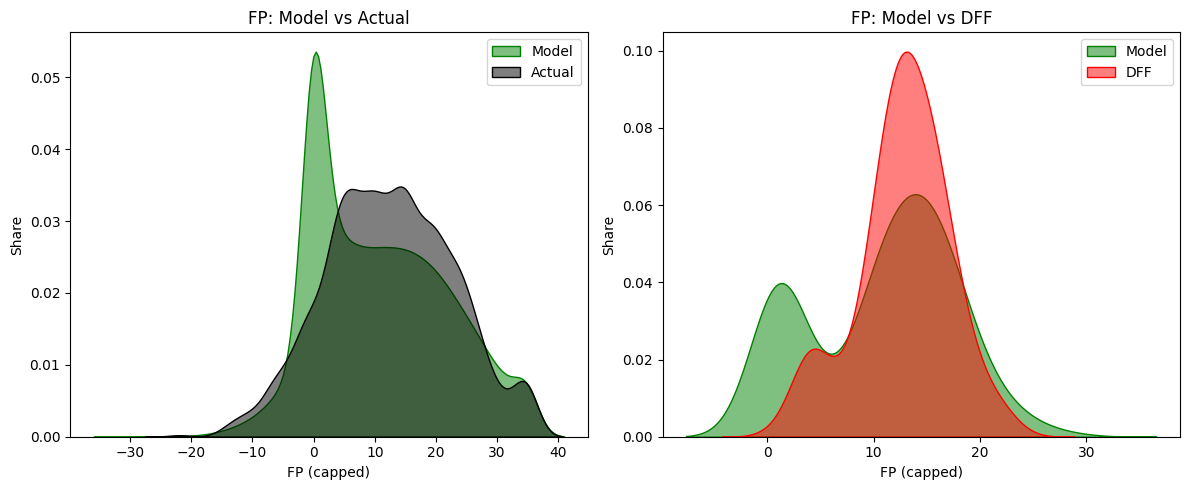

CPU times: total: 3.81 s
Wall time: 3.92 s


In [38]:
%%time
# Cap FP values
FP_capped = np.minimum(pitcher_dataset.query('starter == 1')['FP'], 35)
fp_capped = np.minimum(pitcher_dataset.query('starter == 1')['fp'], 35)

plt.figure(figsize=(12, 5))

# Histogram 1: FP vs fp (Model vs Actual)
plt.subplot(1, 2, 1)
sns.kdeplot(FP_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=2.5)
sns.kdeplot(fp_capped, fill=True, color='black', alpha=0.5, label='Actual', bw_adjust=2.5)
plt.xlabel('FP (capped)')
plt.ylabel('Share')
plt.title('FP: Model vs Actual')
plt.legend()

# Histogram 2: FP vs FP_DFF (grouped, capped)
grouped = pitcher_dataset.query('starter == 1').groupby(['game_id', 'id']).mean(numeric_only=True).reset_index()
FP_grouped_capped = np.minimum(grouped['FP'], 35)
FP_DFF_capped = np.minimum(grouped['FP_DFF'], 35)

plt.subplot(1, 2, 2)
sns.kdeplot(FP_grouped_capped, fill=True, color='green', alpha=0.5, label='Model', bw_adjust=1.5)
sns.kdeplot(FP_DFF_capped, fill=True, color='red', alpha=0.5, label='DFF', bw_adjust=1.5)
plt.xlabel('FP (capped)')
plt.ylabel('Share')
plt.title('FP: Model vs DFF')
plt.legend()

plt.tight_layout()
plt.show()

##### 2C. Batter FP over Time

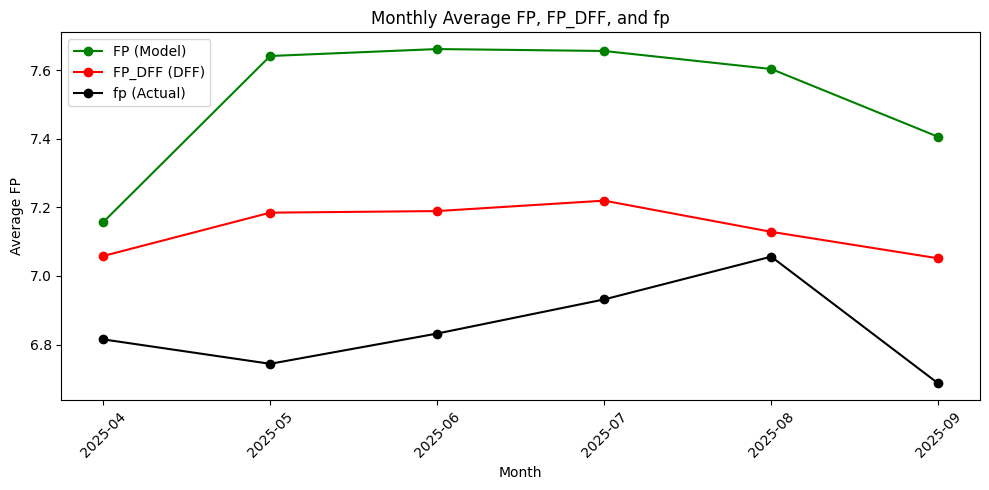

In [39]:
# Convert YYYYMMDD to datetime
batter_dataset['date'] = pd.to_datetime(batter_dataset['date'], format='%Y%m%d', errors='coerce')

# Drop any rows with invalid dates
batter_dataset = batter_dataset.dropna(subset=['date'])

# Filter months April (4) through September (9)
mask = batter_dataset['date'].dt.month.between(4, 9)
batter_filtered = batter_dataset[mask].copy()

# Create 'month' column (year-month)
batter_filtered['month'] = batter_filtered['date'].dt.to_period('M')

# Group by month and compute averages
batter_monthly_avg = batter_filtered.groupby('month')[['FP', 'FP_DFF', 'fp']].mean().reset_index()

# Convert 'month' to string for plotting
batter_monthly_avg['month'] = batter_monthly_avg['month'].astype(str)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(batter_monthly_avg['month'], batter_monthly_avg['FP'], marker='o', color='green', label='FP (Model)')
plt.plot(batter_monthly_avg['month'], batter_monthly_avg['FP_DFF'], marker='o', color='red', label='FP_DFF (DFF)')
plt.plot(batter_monthly_avg['month'], batter_monthly_avg['fp'], marker='o', color='black', label='fp (Actual)')

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average FP')
plt.title('Monthly Average FP, FP_DFF, and fp')
plt.legend()
plt.tight_layout()
plt.show()

##### 2D. Pitcher FP over Time

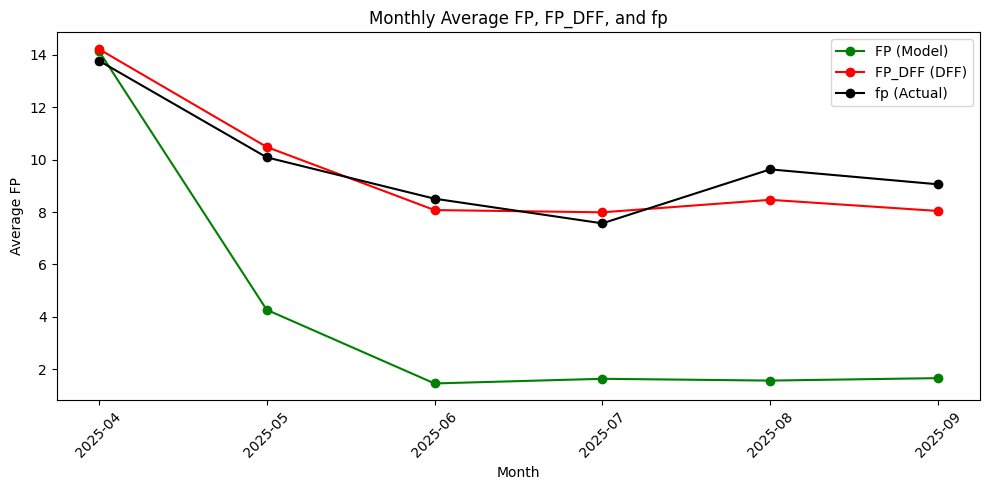

In [40]:
# Convert YYYYMMDD to datetime
pitcher_dataset['date'] = pd.to_datetime(pitcher_dataset['date'], format='%Y%m%d', errors='coerce')

# Drop any rows with invalid dates
# pitcher_dataset = pitcher_dataset.query('starter == 1').dropna(subset=['date'])

# Filter months April (4) through September (9)
mask = pitcher_dataset['date'].dt.month.between(4, 9)
pitcher_filtered = pitcher_dataset.query('starter == 1')[mask].copy()

# Create 'month' column (year-month)
pitcher_filtered['month'] = pitcher_filtered['date'].dt.to_period('M')

# Group by month and compute averages
pitcher_monthly_avg = pitcher_filtered.groupby('month')[['FP', 'FP_DFF', 'fp']].mean().reset_index()

# Convert 'month' to string for plotting
pitcher_monthly_avg['month'] = pitcher_monthly_avg['month'].astype(str)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(pitcher_monthly_avg['month'], pitcher_monthly_avg['FP'], marker='o', color='green', label='FP (Model)')
plt.plot(pitcher_monthly_avg['month'], pitcher_monthly_avg['FP_DFF'], marker='o', color='red', label='FP_DFF (DFF)')
plt.plot(pitcher_monthly_avg['month'], pitcher_monthly_avg['fp'], marker='o', color='black', label='fp (Actual)')

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average FP')
plt.title('Monthly Average FP, FP_DFF, and fp')
plt.legend()
plt.tight_layout()
plt.show()

##### 2E. Batters by Venue

In [41]:
# Step 1: Group by game_id, id, venue_id, venue_name
grouped_players = batter_dataset.query('battingSpotInstance == 1').groupby(['game_id', 'id', 'venue_id', 'venue_name']).mean(numeric_only=True).reset_index()

# Step 2: Venue-level aggregation
venue_avg = grouped_players.groupby(['venue_id', 'venue_name']).agg(
    FP=('FP', 'mean'),
    FP_DFF=('FP_DFF', 'mean'),
    fp=('fp', 'mean'),
    count=('game_id', 'count')
).reset_index()

# Convert venue_id to int
venue_avg['venue_id'] = venue_avg['venue_id'].astype(int)

# Step 3: Filter venues with enough data
venue_avg_filtered = venue_avg[venue_avg['count'] > 10].copy()

# Step 4: Compute differences
venue_avg_filtered['FP_diff'] = venue_avg_filtered['FP'] - venue_avg_filtered['fp']
venue_avg_filtered['FP_DFF_diff'] = venue_avg_filtered['FP_DFF'] - venue_avg_filtered['fp']

# Step 5: Add total/average row
total_row = pd.DataFrame({
    'venue_id': [0],  # use 0 or any int for total row
    'venue_name': ['TOTAL'],
    'FP': [venue_avg_filtered['FP'].mean()],
    'FP_DFF': [venue_avg_filtered['FP_DFF'].mean()],
    'fp': [venue_avg_filtered['fp'].mean()],
    'count': [venue_avg_filtered['count'].sum()],
    'FP_diff': [venue_avg_filtered['FP_diff'].mean()],
    'FP_DFF_diff': [venue_avg_filtered['FP_DFF_diff'].mean()]
})

venue_avg_final = pd.concat([venue_avg_filtered, total_row], ignore_index=True)

# Step 6: Bold + gold background for closer value
def style_closer(row):
    fp_val = row['fp']
    fp_dist = abs(row['FP'] - fp_val)
    dff_dist = abs(row['FP_DFF'] - fp_val)
    
    styles = {}
    if fp_dist < dff_dist:
        styles['FP'] = 'font-weight: bold; background-color: gold'
        styles['FP_DFF'] = ''
    elif dff_dist < fp_dist:
        styles['FP'] = ''
        styles['FP_DFF'] = 'font-weight: bold; background-color: gold'
    else:
        styles['FP'] = ''
        styles['FP_DFF'] = ''
    return pd.Series(styles)

# Step 7: Color function for diff columns
def color_diff(val):
    max_val = 2
    percent = min(abs(val) / max_val, 1) * 50

    if val > 0:
        return f"""
            background: linear-gradient(to right, transparent 50%, red 50%, red {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    elif val < 0:
        return f"""
            background: linear-gradient(to left, transparent 50%, blue 50%, blue {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    else:
        return ''

# Step 8: Apply styling
styler = venue_avg_final.style.apply(style_closer, axis=1)
styler = styler.applymap(color_diff, subset=['FP_diff', 'FP_DFF_diff'])

# Step 9: Format numbers
styler = styler.format({
    'venue_id': '{:.0f}',
    'FP': '{:.2f}',
    'FP_DFF': '{:.2f}',
    'fp': '{:.2f}',
    'FP_diff': '{:.2f}',
    'FP_DFF_diff': '{:.2f}',
    'count': '{:.0f}'
})

styler

,venue_id,venue_name,FP,FP_DFF,fp,count,FP_diff,FP_DFF_diff
0,1,Angel Stadium,7.78,7.22,7.46,1251,0.32,-0.24
1,2,Oriole Park at Camden Yards,7.49,7.33,7.26,1203,0.23,0.07
2,3,Fenway Park,7.22,7.45,7.09,1160,0.13,0.35
3,4,Rate Field,7.08,6.99,6.95,1114,0.13,0.03
4,5,Progressive Field,7.50,7.00,6.54,1237,0.96,0.46
5,7,Kauffman Stadium,7.85,7.20,6.38,1141,1.48,0.83
6,14,Rogers Centre,7.76,7.16,7.54,1153,0.22,-0.38
7,15,Chase Field,8.00,7.47,7.61,1194,0.40,-0.13
8,17,Wrigley Field,7.63,7.24,7.18,1177,0.45,0.06
9,19,Coors Field,8.35,8.07,8.88,1233,-0.54,-0.82


##### 2F. Pitchers by Venue

In [42]:
# Step 1: Group by game_id, id, venue_id, venue_name
grouped_pitchers = pitcher_dataset.query('starter == 1').groupby(['game_id', 'id', 'venue_id', 'venue_name']).mean(numeric_only=True).reset_index()

# Step 2: Venue-level aggregation
venue_avg = grouped_pitchers.groupby(['venue_id', 'venue_name']).agg(
    FP=('FP', 'mean'),
    FP_DFF=('FP_DFF', 'mean'),
    fp=('fp', 'mean'),
    count=('game_id', 'count')
).reset_index()

# Convert venue_id to int
venue_avg['venue_id'] = venue_avg['venue_id'].astype(int)

# Step 3: Filter venues with enough data
venue_avg_filtered = venue_avg[venue_avg['count'] > 10].copy()

# Step 4: Compute differences
venue_avg_filtered['FP_diff'] = venue_avg_filtered['FP'] - venue_avg_filtered['fp']
venue_avg_filtered['FP_DFF_diff'] = venue_avg_filtered['FP_DFF'] - venue_avg_filtered['fp']

# Step 5: Add total/average row
total_row = pd.DataFrame({
    'venue_id': [0],  # int for total row
    'venue_name': ['TOTAL'],
    'FP': [venue_avg_filtered['FP'].mean()],
    'FP_DFF': [venue_avg_filtered['FP_DFF'].mean()],
    'fp': [venue_avg_filtered['fp'].mean()],
    'count': [venue_avg_filtered['count'].sum()],
    'FP_diff': [venue_avg_filtered['FP_diff'].mean()],
    'FP_DFF_diff': [venue_avg_filtered['FP_DFF_diff'].mean()]
})

venue_avg_final = pd.concat([venue_avg_filtered, total_row], ignore_index=True)

# Step 6: Bold + gold background for closer value
def style_closer(row):
    fp_val = row['fp']
    fp_dist = abs(row['FP'] - fp_val)
    dff_dist = abs(row['FP_DFF'] - fp_val)
    
    styles = {}
    if fp_dist < dff_dist:
        styles['FP'] = 'font-weight: bold; background-color: gold'
        styles['FP_DFF'] = ''
    elif dff_dist < fp_dist:
        styles['FP'] = ''
        styles['FP_DFF'] = 'font-weight: bold; background-color: gold'
    else:
        styles['FP'] = ''
        styles['FP_DFF'] = ''
    return pd.Series(styles)

# Step 7: Color function for diff columns
def color_diff(val):
    max_val = 2
    percent = min(abs(val) / max_val, 1) * 50

    if val > 0:
        return f"""
            background: linear-gradient(to right, transparent 50%, red 50%, red {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    elif val < 0:
        return f"""
            background: linear-gradient(to left, transparent 50%, blue 50%, blue {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    else:
        return ''

# Step 8: Apply styling
styler = venue_avg_final.style.apply(style_closer, axis=1)
styler = styler.applymap(color_diff, subset=['FP_diff', 'FP_DFF_diff'])

# Step 9: Format numbers
styler = styler.format({
    'venue_id': '{:.0f}',
    'FP': '{:.2f}',
    'FP_DFF': '{:.2f}',
    'fp': '{:.2f}',
    'FP_diff': '{:.2f}',
    'FP_DFF_diff': '{:.2f}',
    'count': '{:.0f}'
})

styler

,venue_id,venue_name,FP,FP_DFF,fp,count,FP_diff,FP_DFF_diff
0,1,Angel Stadium,9.13,12.33,13.22,26,-4.09,-0.89
1,2,Oriole Park at Camden Yards,9.27,11.99,10.21,37,-0.94,1.78
2,3,Fenway Park,10.02,12.37,13.76,30,-3.74,-1.38
3,4,Rate Field,9.17,11.12,10.61,36,-1.44,0.50
4,5,Progressive Field,11.45,12.45,14.80,39,-3.35,-2.34
5,7,Kauffman Stadium,11.15,12.93,14.72,30,-3.57,-1.79
6,14,Rogers Centre,10.61,12.47,9.00,28,1.61,3.46
7,15,Chase Field,11.42,12.74,11.59,28,-0.16,1.16
8,17,Wrigley Field,10.94,12.25,11.65,32,-0.71,0.60
9,19,Coors Field,9.53,11.78,10.00,34,-0.47,1.78


In [43]:
output_name = f"E02. Evaluate Players {datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.html"
output_dir = os.path.join(baseball_path, "E02. Evaluate Players")

!"{sys.executable}" -m jupyter nbconvert --to html "E02. Evaluate Players.ipynb" --output "{output_name}" --output-dir "{output_dir}"

[NbConvertApp] Converting notebook E02. Evaluate Players.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 805890 bytes to C:\Users\James\Documents\MLB\Data\E02. Evaluate Players\E02. Evaluate Players 2026-02-13_13-13-12.html
